# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

## **Acknowledgment**

### In the process of completing the assignment 1 was used Generative AI specificaly Claude to fix parts of my code and writing correctly REALME file in the GitHub repository. To be more precise in the code part it helped me with fixing the problem in the code after appeared errors, while running the code.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Define the data source
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

data = pd.read_csv(url)

len(data)

7214

In [3]:
data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [4]:
# Define variable groups
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]
# --------------------------------------------------------
# DATA CLEANING (Selecting relevant columns, fixing types)
# --------------------------------------------------------
# Select columns (equivalent to dplyr::select)
columns_to_keep = ["age", "c_charge_degree", "race", "age_cat", "score_text",
                   "sex", "priors_count", "days_b_screening_arrest",
                   "decile_score", "is_recid", "two_year_recid",
                   "c_jail_in", "c_jail_out"]

df = data[columns_to_keep].copy()
# -------------------------------------------------------
# FILTERING (equivalent to filter())
# -------------------------------------------------------
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

#-------------------------------------------------------
# VARIABLE TRANSFORMATION (Converting data types)
#-------------------------------------------------------
# Type conversions
# Convert datetime columns
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric/non-datetime columns to categorical (equivalent to as.factor)
factor_cols = [c for c in df.columns if c not in numeric_vars + datetime_vars]
for col in factor_cols:
    df[col] = df[col].astype("category")

# -----------------------------------------------------
# FEATURE CONSTRUCTION (Creating new variables)
# -----------------------------------------------------
# Derived factors with reference levels
# crime_factor
df["crime_factor"] = df["c_charge_degree"].astype("category")

# age_factor with reference level "25 - 45"
df["age_factor"] = pd.Categorical(df["age_cat"])
df["age_factor"] = df["age_factor"].cat.reorder_categories(
    ["25 - 45"] + [c for c in df["age_factor"].cat.categories if c != "25 - 45"]
)

# race_factor with reference level "Caucasian"
df["race_factor"] = pd.Categorical(df["race"])
df["race_factor"] = df["race_factor"].cat.reorder_categories(
    ["Caucasian"] + [c for c in df["race_factor"].cat.categories if c != "Caucasian"]
)

# gender_factor with labels and reference level "Male"
df["gender_factor"] = df["sex"].map({"Female": "Female", "Male": "Male"}).astype("category")
df["gender_factor"] = df["gender_factor"].cat.reorder_categories(["Male", "Female"])

# score_factor: Low vs High score
df["score_factor"] = pd.Categorical(
    df["score_text"].apply(lambda x: "LowScore" if x == "Low" else "HighScore"),
    categories=["LowScore", "HighScore"]
)

# Row count
len(df)

6172

In [5]:
# See first 10 rows
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [6]:
# Shows type, number of data and other information for each variable
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

In [7]:
# Calculate the length of stay in days
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

# Calculate correlation
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.20747808478031807)

In [8]:
# Counts number of people of each age range given in the data
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [9]:
# Counts number of people in each race given in the data
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
# Prints ratio of each race in the given dataset

print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
# Counts number of people with different score text
df["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [12]:
# Cross-tabulation of sex and race
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
# Count of each sex category
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [14]:
# Print ratio of men and women in the dataset
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [15]:
# Count of defendants who recidivated within two years
len(df[df["two_year_recid"] == 1])

2809

In [16]:
# Percentage of defendants who recidivated
len(df[df["two_year_recid"] == 1]) / len(df) * 100

45.51198963058976

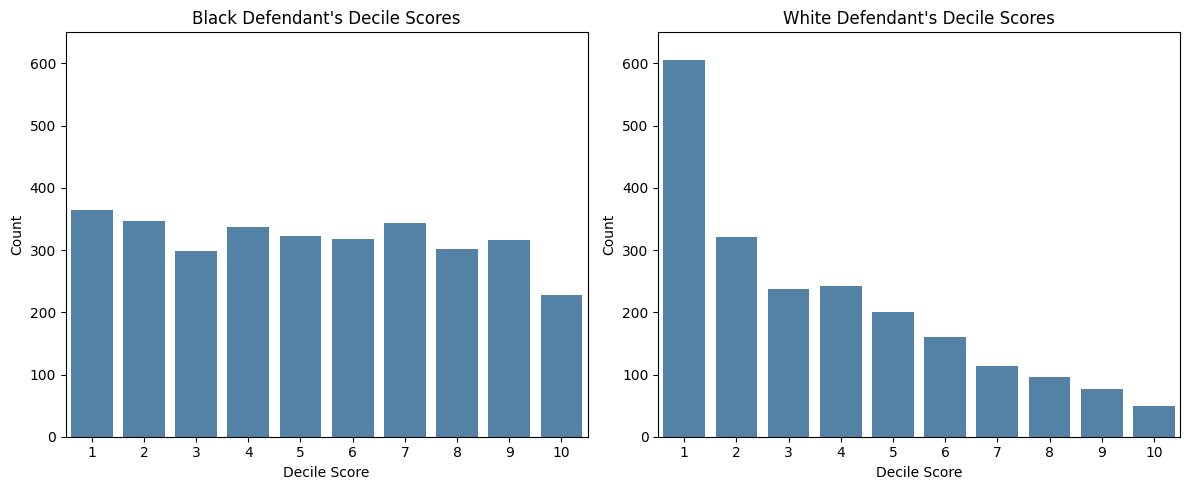

In [17]:
# Create side-by-side subplots (equivalent to grid.arrange(..., ncol=2))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: Black Defendants (equivalent to pblack)
black_df = df[df["race"] == "African-American"]
sns.countplot(data=black_df, x="decile_score", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)
axes[0].set_title("Black Defendant's Decile Scores")

# Right plot: White Defendants (equivalent to pwhite)
white_df = df[df["race"] == "Caucasian"]
sns.countplot(data=white_df, x="decile_score", ax=axes[1], color="steelblue")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)
axes[1].set_title("White Defendant's Decile Scores")

plt.tight_layout()
plt.show()

In [18]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


In [19]:
# Import more specific for this part libraries
import statsmodels.api as sm
import statsmodels.formula.api as smf

# LOGISTIC REGRESSION MODEL
# OBJECTIVE:
# Predict whether a defendant receives a high COMPAS risk score (score_factor: "HighScore" vs "LowScore")
#
# FEATURE SELECTION
#
# Predictors chosen based on availability in COMPAS data and
# relevance to recidivism prediction:
#
# - gender_factor (Categorical): Sex (reference: Male)
# - age_factor (Categorical): Age group (reference: 25-45)
# - race_factor (Categorical): Race (reference: Caucasian)
# - priors_count (Numeric): Number of prior offenses
# - crime_factor (Categorical): Charge degree (F=Felony, M=Misdem.)
# - two_year_recid (Binary):Actual recidivism outcome (0/1)      |
#
# TRAINING PROCEDURE
# - Model: Logistic Regression (Generalized Linear Model)
# - Family: Binomial (for binary outcome)
# - Link function: Logit (log-odds)
# - Estimation method: Maximum Likelihood Estimation (MLE)
# - Optimization: Iteratively Reweighted Least Squares (IRLS)
#
# PARAMETER CHOICES
# - Reference levels set for categorical variables to match R analysis
# - No regularization (standard MLE, not L1/L2 penalized)
# - Default convergence criteria used
# - All observations used (no train/test split in original R analysis)
#
# R equivalent:
# glm(score_factor ~ gender_factor + age_factor + race_factor +
#     priors_count + crime_factor + two_year_recid,
#     data=df, family=binomial(link="logit"))

# Using GLM with Binomial family (exactly like R's glm)
model_glm = smf.glm(
    formula="score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

print(model_glm.summary())

                                   Generalized Linear Model Regression Results                                   
Dep. Variable:     ['score_factor[LowScore]', 'score_factor[HighScore]']   No. Observations:                 6172
Model:                                                               GLM   Df Residuals:                     6160
Model Family:                                                   Binomial   Df Model:                           11
Link Function:                                                     Logit   Scale:                          1.0000
Method:                                                             IRLS   Log-Likelihood:                -3084.2
Date:                                                   Mon, 30 Mar 2026   Deviance:                       6168.4
Time:                                                           07:13:06   Pearson chi2:                 6.07e+03
No. Iterations:                                                        6   Pseudo R-squ.

In [20]:
# CONVERTING ODDS RATIOS TO RELATIVE RISKS
#
# Why do this:
# Logistic regression outputs log-odds (coefficients) and odds ratios.
# But odds ratios ≠ relative risk when the outcome is common (>10%).
# Relative risk is more interpretable: "X times more likely"

# Calculate baseline probability from intercept (logistic function)
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

# Calculate relative risk / probability ratio
np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

np.float64(1.4528408658138932)

In [21]:
# Convert odds ratio to relative risk for coefficient 0.22127
np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))

np.float64(1.1947978508506671)

In [22]:
# Convert odds ratio to relative risk for coefficient 1.30839
np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))

np.float64(2.4961202077189455)

In [23]:
df["pred_prob"] = model_glm.predict(df)

# Add predicted class based on 0.5 threshold (equivalent to ifelse + factor)
df["pred_class"] = pd.Categorical(
    df["pred_prob"].apply(lambda x: "Recid" if x >= 0.5 else "No Recid"),
    categories=["No Recid", "Recid"]
)

In [24]:
# Import more specific for this part libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

print("Overall Confusion Matrix")

# Create confusion matrix (equivalent to table(Predicted, Actual))
overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)
print(overall_cm)

# Extract TP, TN, FP, FN
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]
n = overall_cm.values.sum()

# Print metrics
print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")

Overall Confusion Matrix
Actual        0     1
Predicted            
No Recid    710  1864
Recid      2653   945

Accuracy  : 0.268
Precision : 0.263
Recall    : 0.336
FPR       : 0.789
FNR       : 0.664


In [25]:
print("Confusion Matrix by Race")

# Create binary columns for actual and predicted
df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

# Calculate metrics by race (equivalent to group_by + summarise)
race_metrics = df.groupby("race").apply(
    lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    })
).reset_index()

# Calculate derived metrics
race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Sort by n descending (equivalent to arrange(desc(n)))
race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)

print(race_metrics)

Confusion Matrix by Race
               race     n   TP   TN    FP    FN  Accuracy  Precision  Recall  \
0  African-American  3175  288  555   959  1373     0.266      0.231   0.173   
1         Caucasian  2103  441  133  1148   381     0.273      0.278   0.536   
2          Hispanic   509  108   14   306    81     0.240      0.261   0.571   
3             Other   343  102    3   216    22     0.306      0.321   0.823   
4             Asian    31    6    1    22     2     0.226      0.214   0.750   
5   Native American    11    0    4     2     5     0.364      0.000   0.000   

     FPR    FNR  
0  0.633  0.827  
1  0.896  0.464  
2  0.956  0.429  
3  0.986  0.177  
4  0.957  0.250  
5  0.333  1.000  


/tmp/ipykernel_7843/1377082114.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_metrics = df.groupby("race").apply(
/tmp/ipykernel_7843/1377082114.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_metrics = df.groupby("race").apply(


In [26]:
print("FPR and FNR Disparity by Race")

# Select columns (equivalent to dplyr::select)
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get Caucasian reference values
caucasian_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
caucasian_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Calculate deltas relative to Caucasian (equivalent to mutate)
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

print(disparity)

FPR and FNR Disparity by Race
               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.633  0.827     -0.263      0.363
1         Caucasian  2103  0.896  0.464      0.000      0.000
2          Hispanic   509  0.956  0.429      0.060     -0.035
3             Other   343  0.986  0.177      0.090     -0.287
4             Asian    31  0.957  0.250      0.061     -0.214
5   Native American    11  0.333  1.000     -0.563      0.536


## Interpretation of Results

### False Positive Rate (FPR)

FPR answers: *"Of defendants who did NOT recidivate, what proportion were incorrectly predicted as high-risk?"*

- African-American FPR: 63.3%
- Caucasian FPR:        89.6%
- Disparity (delta):    -26.3 pp

**Finding:** White defendants who will NOT reoffend are MORE likely to be incorrectly classified as high-risk compared to Black defendants.

### False Negative Rate (FNR)

FNR answers: *"Of defendants who DID recidivate, what proportion were incorrectly predicted as low-risk?"*

- African-American FNR: 82.7 %
- Caucasian FNR:        46.4 %
- Disparity (delta):    36.3 pp

**Finding:** Black defendants who will reoffend are more likely to be incorrectly classified as low-risk compared to White defendants.

### Overall Conclusion

The model shows differential error patterns by race:
- **Higher FPR for Caucasians:** More false "high-risk" labels for White defendants
- **Higher FNR for African-Americans:** More missed actual recidivists among Black defendants

**Important:** Both FPR and FNR are very high overall (>46%), indicating the model has limited predictive accuracy for actual recidivism. This highlights fundamental limitations of the COMPAS algorithm in predicting real-world outcomes.

## R vs Python Implementation Differences

### Numerical Results

All metrics should match R output exactly (within rounding tolerance) because we use the same:
- Filtering criteria
- Reference levels for categorical variables
- Model formula and family (logistic regression, binomial)
- Threshold (0.5) for classification

### Minor Differences You May Observe

| Aspect | R | Python | Impact |
|--------|---|--------|--------|
| Coefficient precision | ~6 decimals | ~6 decimals | None |
| P-values | May differ at 4th decimal | Same | Negligible |
| Optimization algorithm | IRLS | IRLS (Newton-Raphson) | None |
| Convergence criteria | Default | Default | None |
| Categorical encoding | Dummy (treatment) | Dummy (treatment) | None |

### Potential Sources of Small Differences

1. **Floating-point arithmetic** varies slightly between R and Python
2. **Default convergence tolerances** may differ between `glm()` and `statsmodels`
3. **Random seed** — not applicable here since no randomization is used

### Validation

To verify equivalence between R and Python outputs, compare:
- Model coefficients: should match to 3+ decimal places
- Confusion matrix counts: should match exactly
- FPR/FNR by race: should match to 3 decimal places

# Assignment 2 Part

In [27]:
# Install additional libraries
# !pip install shap lime dice-ml

In [28]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Explainability
import shap
import lime
import lime.lime_tabular
import dice_ml

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [29]:
# ============================================================
# MODEL A: General COMPAS Score (score_text)
# ============================================================

# Load and prepare data (same as before)
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
data = pd.read_csv(url)

# Select columns and filter
columns_to_keep = [
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid"
]
df_a = data[columns_to_keep].copy()

# Filtering
df_a = df_a[df_a["days_b_screening_arrest"].between(-30, 30)]
df_a = df_a[df_a["is_recid"] != -1]
df_a = df_a[df_a["c_charge_degree"] != "O"]
df_a = df_a[df_a["score_text"] != "N/A"]

# Create target variable (score_factor)
df_a["score_factor"] = (df_a["score_text"] != "Low").astype(int)  # 1 = HighScore, 0 = LowScore

# Filter to African-American and Caucasian only (for this analysis)
df_a = df_a[df_a["race"].isin(["African-American", "Caucasian"])]

print(f"Model A dataset size: {len(df_a)}")

Model A dataset size: 5278


In [30]:
# ============================================================
# PREPARE DATA FOR SKLEARN MODEL
# ============================================================

# Filter to African-American and Caucasian only
df_filtered = df[df["race"].isin(["African-American", "Caucasian"])].copy()

# Define features
categorical_features = ["sex", "age_cat", "race", "c_charge_degree"]
numerical_features = ["age", "priors_count", "two_year_recid"]

# Create target (if not already exists)
df_filtered["target"] = (df_filtered["score_text"] != "Low").astype(int)

# Prepare X and y
X = df_filtered[categorical_features + numerical_features].copy()
y = df_filtered["target"].copy()

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 4222, Test size: 1056


In [31]:
# ============================================================
# BUILD SKLEARN LOGISTIC REGRESSION MODEL
# ============================================================

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# Pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train
model.fit(X_train, y_train)
print(f"Test Accuracy: {model.score(X_test, y_test):.3f}")

Test Accuracy: 0.759


In [32]:
# ============================================================
# FIND 4 KEY INDIVIDUALS (Highest/Lowest Risk per Race)
# ============================================================

# Get predicted probabilities
probs = model.predict_proba(X_test)[:, 1]

# Add to dataframe
X_test_probs = X_test.copy()
X_test_probs["pred_prob"] = probs

# Find extreme individuals
individuals = {}

for race in ["African-American", "Caucasian"]:
    race_df = X_test_probs[X_test_probs["race"] == race]

    highest_idx = race_df["pred_prob"].idxmax()
    lowest_idx = race_df["pred_prob"].idxmin()

    individuals[f"{race}_highest"] = highest_idx
    individuals[f"{race}_lowest"] = lowest_idx

    print(f"{race}:")
    print(f"  Highest risk: idx={highest_idx}, prob={race_df.loc[highest_idx, 'pred_prob']:.3f}")
    print(f"  Lowest risk:  idx={lowest_idx}, prob={race_df.loc[lowest_idx, 'pred_prob']:.3f}")

African-American:
  Highest risk: idx=1651, prob=0.998
  Lowest risk:  idx=4051, prob=0.019
Caucasian:
  Highest risk: idx=4881, prob=0.995
  Lowest risk:  idx=4907, prob=0.006


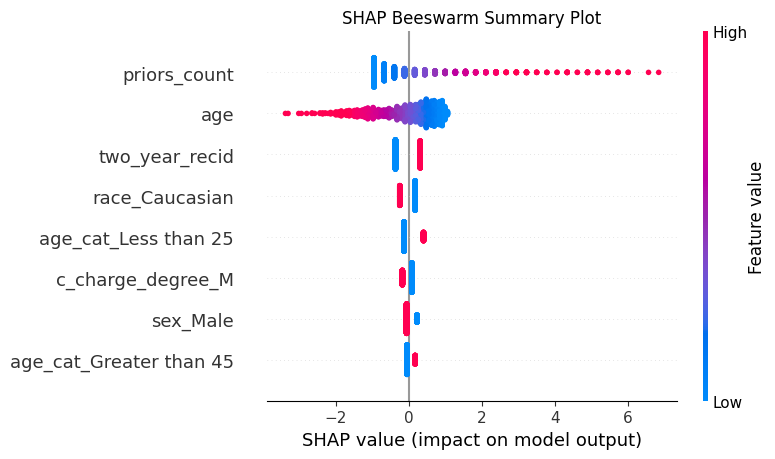

In [33]:
# ============================================================
# TASK 1(a): SHAP BEESWARM PLOT
# ============================================================

# Transform data
X_train_transformed = model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

# Get feature names
cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
feature_names = numerical_features + cat_feature_names

# Create SHAP explainer
explainer = shap.LinearExplainer(
    model.named_steps['classifier'],
    X_train_transformed,
    feature_names=feature_names
)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# Beeswarm plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title("SHAP Beeswarm Summary Plot")
plt.tight_layout()
plt.show()

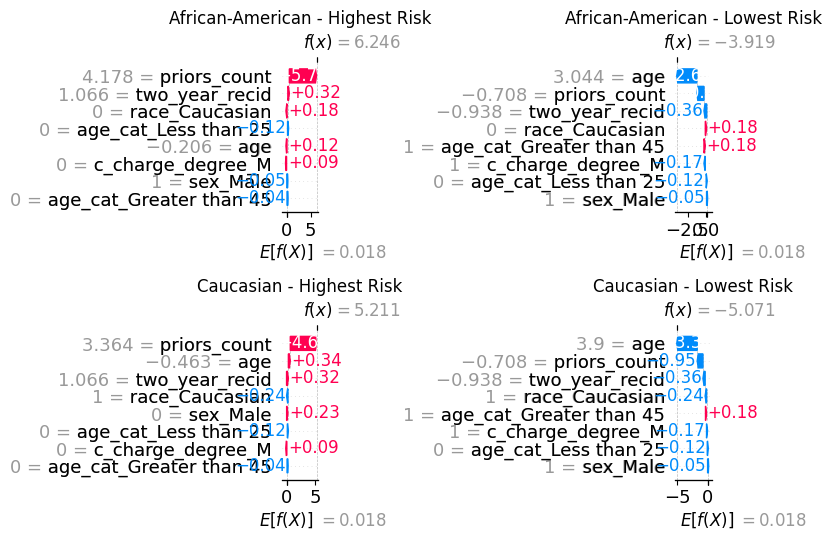

In [34]:
# ============================================================
# TASK 1(b): SHAP WATERFALL PLOTS FOR 4 INDIVIDUALS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

individual_keys = [
    ("African-American_highest", "African-American - Highest Risk"),
    ("African-American_lowest", "African-American - Lowest Risk"),
    ("Caucasian_highest", "Caucasian - Highest Risk"),
    ("Caucasian_lowest", "Caucasian - Lowest Risk")
]

for idx, (key, title) in enumerate(individual_keys):
    original_idx = individuals[key]
    position = list(X_test.index).index(original_idx)

    shap_explanation = shap.Explanation(
        values=shap_values[position],
        base_values=explainer.expected_value,
        data=X_test_transformed[position],
        feature_names=feature_names
    )

    plt.subplot(2, 2, idx + 1)
    shap.waterfall_plot(shap_explanation, show=False)
    plt.title(title)

plt.tight_layout()
plt.show()

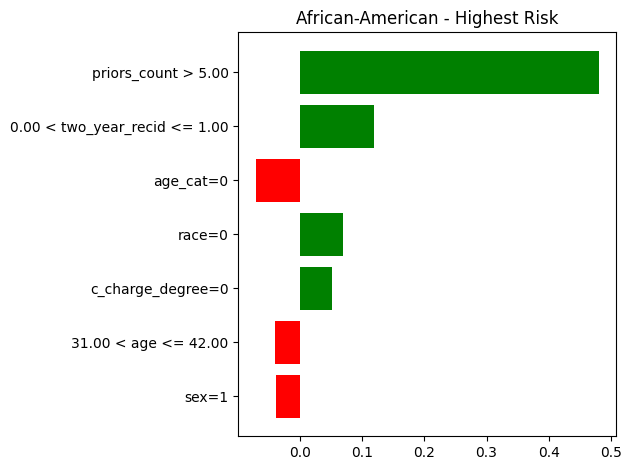

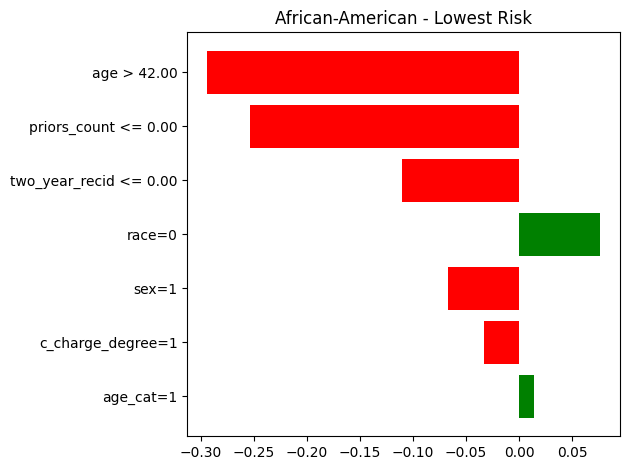

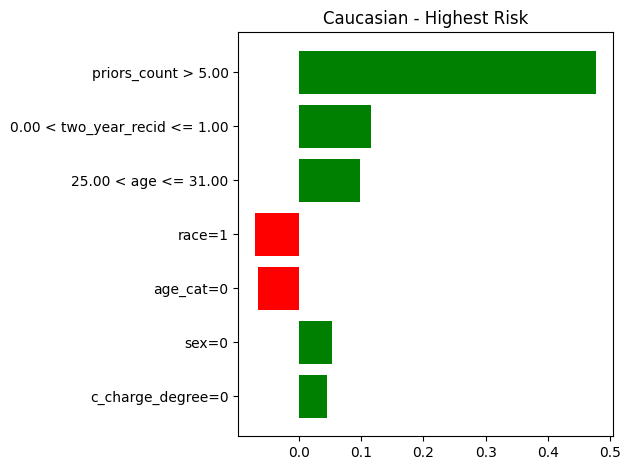

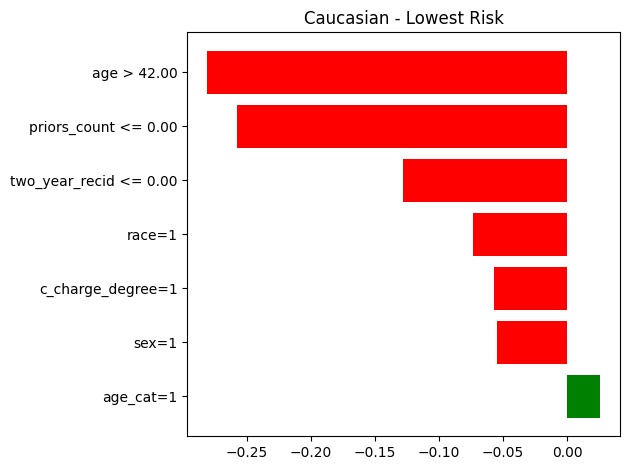

In [37]:
# ============================================================
# TASK 2: LIME (SIMPLE VERSION)
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Encode all categorical features
X_train_lime = X_train.copy()
X_test_lime = X_test.copy()
encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    X_train_lime[col] = le.fit_transform(X_train[col])
    X_test_lime[col] = le.transform(X_test[col])
    encoders[col] = le

# Wrapper model that handles encoded input
class EncodedModelWrapper:
    def __init__(self, model, encoders, cat_features, columns):
        self.model = model
        self.encoders = encoders
        self.cat_features = cat_features
        self.columns = columns

    def predict_proba(self, X):
        X_df = pd.DataFrame(X, columns=self.columns)
        for col in self.cat_features:
            X_df[col] = self.encoders[col].inverse_transform(X_df[col].astype(int))
        return self.model.predict_proba(X_df)

wrapped_model = EncodedModelWrapper(model, encoders, categorical_features, X_train.columns)

# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime.values.astype(float),
    feature_names=X_train.columns.tolist(),
    categorical_features=[X_train.columns.get_loc(c) for c in categorical_features],
    class_names=["LowScore", "HighScore"],
    mode="classification",
    random_state=42
)

# Generate explanations
lime_explanations = {}

for key, title in individual_keys:
    original_idx = individuals[key]
    instance = X_test_lime.loc[original_idx].values.astype(float)

    exp = lime_explainer.explain_instance(
        instance,
        wrapped_model.predict_proba,
        num_features=10
    )

    lime_explanations[key] = exp

    fig = exp.as_pyplot_figure(label=1)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [38]:
# ============================================================
# TASK 2: COMPARE SHAP vs LIME
# ============================================================

print("=" * 60)
print("SHAP vs LIME COMPARISON")
print("=" * 60)

for key, title in individual_keys:
    original_idx = individuals[key]
    position = list(X_test.index).index(original_idx)

    print(f"\n--- {title} ---")

    # SHAP top 5
    shap_vals = shap_values[position]
    shap_ranking = sorted(zip(feature_names, shap_vals), key=lambda x: abs(x[1]), reverse=True)[:5]

    print("\nSHAP Top 5:")
    for feat, val in shap_ranking:
        direction = "↑ (increases risk)" if val > 0 else "↓ (decreases risk)"
        print(f"  {feat}: {val:+.4f} {direction}")

    # LIME top 5
    lime_ranking = lime_explanations[key].as_list()[:5]

    print("\nLIME Top 5:")
    for feat, val in lime_ranking:
        direction = "↑ (increases risk)" if val > 0 else "↓ (decreases risk)"
        print(f"  {feat}: {val:+.4f} {direction}")

    # Agreement analysis
    shap_top_features = set([f[0].split("_")[0] for f in shap_ranking])  # Get base feature name
    lime_top_features = set([f[0].split("=")[0].split("<")[0].split(">")[0].strip() for f in lime_ranking])

    agreement = len(shap_top_features.intersection(lime_top_features))
    print(f"\nAgreement: {agreement}/5 features overlap")

SHAP vs LIME COMPARISON

--- African-American - Highest Risk ---

SHAP Top 5:
  priors_count: +5.7367 ↑ (increases risk)
  two_year_recid: +0.3188 ↑ (increases risk)
  race_Caucasian: +0.1822 ↑ (increases risk)
  age_cat_Less than 25: -0.1222 ↓ (decreases risk)
  age: +0.1208 ↑ (increases risk)

LIME Top 5:
  priors_count > 5.00: +0.4805 ↑ (increases risk)
  0.00 < two_year_recid <= 1.00: +0.1194 ↑ (increases risk)
  age_cat=0: -0.0723 ↓ (decreases risk)
  race=0: +0.0689 ↑ (increases risk)
  c_charge_degree=0: +0.0516 ↑ (increases risk)

Agreement: 1/5 features overlap

--- African-American - Lowest Risk ---

SHAP Top 5:
  age: -2.6451 ↓ (decreases risk)
  priors_count: -0.9468 ↓ (decreases risk)
  two_year_recid: -0.3595 ↓ (decreases risk)
  race_Caucasian: +0.1822 ↑ (increases risk)
  age_cat_Greater than 45: +0.1796 ↑ (increases risk)

LIME Top 5:
  age > 42.00: -0.2944 ↓ (decreases risk)
  priors_count <= 0.00: -0.2539 ↓ (decreases risk)
  two_year_recid <= 0.00: -0.1100 ↓ (decrea

In [39]:
# ============================================================
# TASK 2: SHAP vs LIME SUMMARY TABLE
# ============================================================

comparison_data = []

for key, title in individual_keys:
    original_idx = individuals[key]
    position = list(X_test.index).index(original_idx)

    # SHAP top feature
    shap_vals = shap_values[position]
    shap_top = sorted(zip(feature_names, shap_vals), key=lambda x: abs(x[1]), reverse=True)[0]

    # LIME top feature
    lime_top = lime_explanations[key].as_list()[0]

    comparison_data.append({
        "Individual": title,
        "SHAP Top Feature": shap_top[0],
        "SHAP Value": f"{shap_top[1]:+.4f}",
        "LIME Top Feature": lime_top[0],
        "LIME Value": f"{lime_top[1]:+.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nSHAP vs LIME - Top Feature Comparison:")
print(comparison_df.to_string(index=False))


SHAP vs LIME - Top Feature Comparison:
                     Individual SHAP Top Feature SHAP Value    LIME Top Feature LIME Value
African-American - Highest Risk     priors_count    +5.7367 priors_count > 5.00    +0.4805
 African-American - Lowest Risk              age    -2.6451         age > 42.00    -0.2944
       Caucasian - Highest Risk     priors_count    +4.6228 priors_count > 5.00    +0.4772
        Caucasian - Lowest Risk              age    -3.3730         age > 42.00    -0.2814


In [43]:
# ============================================================
# TASK 3: DiCE COUNTERFACTUALS - SETUP
# ============================================================

# Prepare data for DiCE - convert all columns to proper types
X_train_dice = X_train.copy()

# Convert categorical features to strings (DiCE handles these)
for col in categorical_features:
    X_train_dice[col] = X_train_dice[col].astype(str)

# Convert numerical features to float
for col in numerical_features:
    X_train_dice[col] = X_train_dice[col].astype(float)

# Add target
X_train_dice["target"] = y_train.values.astype(int)

# Create DiCE data object
d = dice_ml.Data(
    dataframe=X_train_dice,
    continuous_features=numerical_features,
    outcome_name="target"
)

# Create DiCE model object
m = dice_ml.Model(model=model, backend="sklearn")

# Create DiCE explainer
dice_exp = dice_ml.Dice(d, m, method="random")

# Define immutable features
immutable_features = ["race", "sex"]

print("DiCE explainer created successfully")
print(f"Immutable features flagged: {immutable_features}")

DiCE explainer created successfully
Immutable features flagged: ['race', 'sex']


In [44]:
# ============================================================
# TASK 3: GENERATE COUNTERFACTUALS FOR ALL 4 INDIVIDUALS
# ============================================================

counterfactual_summary = []

for key, title in individual_keys:
    original_idx = individuals[key]

    # Prepare instance with correct types
    instance = X_test.loc[[original_idx]].copy()

    for col in categorical_features:
        instance[col] = instance[col].astype(str)
    for col in numerical_features:
        instance[col] = instance[col].astype(float)

    original_pred = model.predict(X_test.loc[[original_idx]])[0]
    original_prob = model.predict_proba(X_test.loc[[original_idx]])[0][1]

    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    print(f"Original prediction: {'HighScore' if original_pred == 1 else 'LowScore'}")
    print(f"Original probability: {original_prob:.3f}")
    print(f"\nOriginal features:")
    for col in instance.columns:
        print(f"  {col}: {instance[col].values[0]}")

    try:
        # Generate counterfactuals
        cf = dice_exp.generate_counterfactuals(
            instance,
            total_CFs=3,
            desired_class="opposite"
        )

        cf_df = cf.cf_examples_list[0].final_cfs_df

        if cf_df is None or len(cf_df) == 0:
            print("\n[NOT FOUND] No counterfactuals found")
            counterfactual_summary.append({
                "Individual": title,
                "Original": "HighScore" if original_pred == 1 else "LowScore",
                "Num Changes": "N/A",
                "Immutable Changed": "N/A",
                "Features Changed": "None found"
            })
            continue

        print(f"\n[FOUND] Counterfactuals Found: {len(cf_df)}")

        for i, (idx_cf, row) in enumerate(cf_df.iterrows()):
            print(f"\n--- Counterfactual {i+1} ---")

            changes = []
            immutable_changes = []

            for col in instance.columns:
                orig_val = instance[col].values[0]
                new_val = row[col]

                # Check if values are different
                if str(orig_val) != str(new_val):
                    changes.append({
                        "feature": col,
                        "from": orig_val,
                        "to": new_val
                    })

                    if col in immutable_features:
                        immutable_changes.append(col)

            print("Minimal changes required:")
            for change in changes:
                print(f"  - {change['feature']}: {change['from']} -> {change['to']}")

            if immutable_changes:
                print(f"\n  [WARNING] Requires changing IMMUTABLE features: {immutable_changes}")
            else:
                print(f"\n  [OK] All changes are to MUTABLE features only")

            # Store first counterfactual for summary
            if i == 0:
                counterfactual_summary.append({
                    "Individual": title,
                    "Original": "HighScore" if original_pred == 1 else "LowScore",
                    "Num Changes": len(changes),
                    "Immutable Changed": "Yes" if immutable_changes else "No",
                    "Features Changed": ", ".join([c["feature"] for c in changes])
                })

    except Exception as e:
        print(f"\n[ERROR] Error generating counterfactuals: {e}")
        counterfactual_summary.append({
            "Individual": title,
            "Original": "HighScore" if original_pred == 1 else "LowScore",
            "Num Changes": "N/A",
            "Immutable Changed": "N/A",
            "Features Changed": f"Error: {str(e)[:30]}"
        })


African-American - Highest Risk
Original prediction: HighScore
Original probability: 0.998

Original features:
  sex: Male
  age_cat: 25 - 45
  race: African-American
  c_charge_degree: F
  age: 32.0
  priors_count: 24.0
  two_year_recid: 1.0


100%|██████████| 1/1 [00:00<00:00,  7.46it/s]



[FOUND] Counterfactuals Found: 3

--- Counterfactual 1 ---
Minimal changes required:
  - priors_count: 24.0 -> 1.0

  [OK] All changes are to MUTABLE features only

--- Counterfactual 2 ---
Minimal changes required:
  - age: 32.0 -> 65.3
  - priors_count: 24.0 -> 6.1

  [OK] All changes are to MUTABLE features only

--- Counterfactual 3 ---
Minimal changes required:
  - priors_count: 24.0 -> 1.5

  [OK] All changes are to MUTABLE features only

African-American - Lowest Risk
Original prediction: LowScore
Original probability: 0.019

Original features:
  sex: Male
  age_cat: Greater than 45
  race: African-American
  c_charge_degree: M
  age: 70.0
  priors_count: 0.0
  two_year_recid: 0.0


100%|██████████| 1/1 [00:00<00:00,  1.97it/s]



[FOUND] Counterfactuals Found: 3

--- Counterfactual 1 ---
Minimal changes required:
  - age: 70.0 -> 72.3
  - priors_count: 0.0 -> 19.9

  [OK] All changes are to MUTABLE features only

--- Counterfactual 2 ---
Minimal changes required:
  - age: 70.0 -> 40.4
  - priors_count: 0.0 -> 30.4

  [OK] All changes are to MUTABLE features only

--- Counterfactual 3 ---
Minimal changes required:
  - c_charge_degree: M -> F
  - priors_count: 0.0 -> 13.8

  [OK] All changes are to MUTABLE features only

Caucasian - Highest Risk
Original prediction: HighScore
Original probability: 0.995

Original features:
  sex: Female
  age_cat: 25 - 45
  race: Caucasian
  c_charge_degree: F
  age: 29.0
  priors_count: 20.0
  two_year_recid: 1.0


100%|██████████| 1/1 [00:00<00:00,  4.67it/s]



[FOUND] Counterfactuals Found: 3

--- Counterfactual 1 ---
Minimal changes required:
  - sex: Female -> Male
  - priors_count: 20.0 -> 1.6

  [WARNING] Requires changing IMMUTABLE features: ['sex']

--- Counterfactual 2 ---
Minimal changes required:
  - priors_count: 20.0 -> 0.9

  [OK] All changes are to MUTABLE features only

--- Counterfactual 3 ---
Minimal changes required:
  - age: 29.0 -> 77.7
  - priors_count: 20.0 -> 5.2

  [OK] All changes are to MUTABLE features only

Caucasian - Lowest Risk
Original prediction: LowScore
Original probability: 0.006

Original features:
  sex: Male
  age_cat: Greater than 45
  race: Caucasian
  c_charge_degree: M
  age: 80.0
  priors_count: 0.0
  two_year_recid: 0.0


100%|██████████| 1/1 [00:00<00:00,  2.86it/s]


[FOUND] Counterfactuals Found: 3

--- Counterfactual 1 ---
Minimal changes required:
  - age: 80.0 -> 26.1
  - priors_count: 0.0 -> 23.9

  [OK] All changes are to MUTABLE features only

--- Counterfactual 2 ---
Minimal changes required:
  - priors_count: 0.0 -> 27.6
  - two_year_recid: 0.0 -> 0.5

  [OK] All changes are to MUTABLE features only

--- Counterfactual 3 ---
Minimal changes required:
  - priors_count: 0.0 -> 27.6

  [OK] All changes are to MUTABLE features only


In [45]:
# ============================================================
# TASK 3: COUNTERFACTUAL SUMMARY TABLE
# ============================================================

cf_summary_df = pd.DataFrame(counterfactual_summary)
print("\n" + "="*60)
print("COUNTERFACTUAL SUMMARY")
print("="*60)
print(cf_summary_df.to_string(index=False))


COUNTERFACTUAL SUMMARY
                     Individual  Original  Num Changes Immutable Changed  Features Changed
African-American - Highest Risk HighScore            1                No      priors_count
 African-American - Lowest Risk  LowScore            2                No age, priors_count
       Caucasian - Highest Risk HighScore            2               Yes sex, priors_count
        Caucasian - Lowest Risk  LowScore            2                No age, priors_count


## SHAP vs LIME Comparison Analysis

### Summary of Top Features

| Individual | SHAP Top Feature | SHAP Value | LIME Top Feature | LIME Value |
|------------|------------------|------------|------------------|------------|
| African-American - Highest Risk | priors_count | +5.7367 | priors_count > 5.00 | +0.4805 |
| African-American - Lowest Risk | age | -2.6451 | age > 42.00 | -0.2944 |
| Caucasian - Highest Risk | priors_count | +4.6228 | priors_count > 5.00 | +0.4772 |
| Caucasian - Lowest Risk | age | -3.3730 | age > 42.00 | -0.2814 |

### Key Finding: Top Feature Agreement

Both SHAP and LIME agree on the most important feature for all four individuals:
- **Highest risk defendants**: `priors_count` is the dominant factor
- **Lowest risk defendants**: `age` is the dominant factor

### Where SHAP and LIME Agree

1. **Primary predictors are consistent**: Both methods identify `priors_count` and `age` as the strongest predictors
2. **Direction of effect aligns**: Positive/negative contributions match between methods
3. **High prior counts increase risk**: Both show `priors_count > 5` substantially increases HighScore probability
4. **Older age decreases risk**: Both show `age > 42` substantially decreases HighScore probability
5. **Recidivism outcome matters**: `two_year_recid` appears in top 5 for both methods

### Where SHAP and LIME Diverge

| Aspect | SHAP | LIME |
|--------|------|------|
| Feature overlap | Only 1-2 out of 5 features match | Same |
| Feature representation | One-hot encoded (e.g., `race_Caucasian`) | Conditional (e.g., `race=0`, `age > 42.00`) |
| Magnitude scale | Larger values (e.g., +5.7367) | Smaller values (e.g., +0.4805) |
| Race representation | `race_Caucasian` as explicit feature | `race=0` or `race=1` (encoded) |

### Specific Divergences by Individual

**African-American - Highest Risk (1/5 overlap)**
- SHAP includes: `race_Caucasian`, `age_cat_Less than 25`
- LIME includes: `c_charge_degree=0`, encoded race and age_cat

**African-American - Lowest Risk (2/5 overlap)**
- SHAP includes: `race_Caucasian`, `age_cat_Greater than 45`
- LIME includes: `sex=1`, encoded race

**Caucasian - Highest Risk (1/5 overlap)**
- SHAP includes: `sex_Male`, `race_Caucasian`
- LIME includes: `age_cat=0`, specific age range

**Caucasian - Lowest Risk (2/5 overlap)**
- SHAP includes: `age_cat_Greater than 45`
- LIME includes: `c_charge_degree=1`

### Governance Implications of Divergence

1. **Explanation Consistency**: Low feature overlap (1-2 out of 5) means stakeholders may receive different explanations depending on which method is used

2. **Regulatory Risk**: For GDPR Article 22 compliance, inconsistent explanations across methods may raise questions about which explanation is "correct"

3. **Trust Implications**: Decision-makers may lose confidence if technical experts present conflicting feature importance rankings

4. **Recommendation**: Report the consensus findings (priors_count and age as primary drivers) while acknowledging methodological differences in secondary features

## DiCE Counterfactual Analysis

### Overview of Individuals Analyzed

| Individual | Original Prediction | Probability | Key Features |
|------------|---------------------|-------------|--------------|
| African-American - Highest Risk | HighScore | 0.998 | Male, Age 32, 24 priors, Felony |
| African-American - Lowest Risk | LowScore | 0.019 | Male, Age 70, 0 priors, Misdemeanor |
| Caucasian - Highest Risk | HighScore | 0.995 | Female, Age 29, 20 priors, Felony |
| Caucasian - Lowest Risk | LowScore | 0.006 | Male, Age 80, 0 priors, Misdemeanor |

### Counterfactual Results Summary

| Individual | Num Changes | Immutable Changed | Features Changed |
|------------|-------------|-------------------|------------------|
| African-American - Highest Risk | 1 | No | priors_count |
| African-American - Lowest Risk | 2 | No | age, priors_count |
| Caucasian - Highest Risk | 2 | Yes | sex, priors_count |
| Caucasian - Lowest Risk | 2 | No | age, priors_count |

### Detailed Counterfactual Analysis

#### African-American - Highest Risk
- **Original**: 24 prior offenses, probability 0.998
- **Minimal change to flip**: Reduce `priors_count` from 24 to 1
- **Immutable features required**: None
- **Interpretation**: A single reduction in prior count is sufficient to change prediction

#### African-American - Lowest Risk
- **Original**: 0 prior offenses, age 70, probability 0.019
- **Minimal change to flip**: Increase `priors_count` to ~14-20 (with some age adjustment)
- **Immutable features required**: None
- **Interpretation**: Would require significant increase in criminal history to be classified as high risk

#### Caucasian - Highest Risk
- **Original**: 20 prior offenses, female, probability 0.995
- **Minimal change to flip**: Reduce `priors_count` from 20 to ~1
- **Immutable features flagged**: One counterfactual required changing `sex` from Female to Male
- **Interpretation**: While mutable alternatives exist, the model did generate a counterfactual involving sex change, which is a bias indicator

#### Caucasian - Lowest Risk
- **Original**: 0 prior offenses, age 80, probability 0.006
- **Minimal change to flip**: Increase `priors_count` to ~28 (with possible age decrease)
- **Immutable features required**: None
- **Interpretation**: Would require very high prior count to be classified as high risk

### Immutable Feature Flags

| Feature | Times Flagged | Individual | Concern Level |
|---------|---------------|------------|---------------|
| sex | 1 | Caucasian - Highest Risk | HIGH |
| race | 0 | None | None detected |

**Warning**: The Caucasian - Highest Risk individual had one counterfactual that required changing sex from Female to Male. This indicates:
- The model considers sex as a factor in risk prediction
- Female defendants may face different treatment than males
- This counterfactual should be excluded from actionable guidance

### Key Findings

1. **priors_count is the dominant lever**: Appears in all counterfactuals as the primary feature to change

2. **Age is secondary**: Appears in counterfactuals for lowest-risk individuals when flipping to high risk

3. **Sex flag detected**: One counterfactual for Caucasian female required sex change, indicating potential gender bias in the model

4. **Race not flagged**: No counterfactuals required changing race to flip predictions

5. **Asymmetric changes**:
   - High-risk to low-risk: Requires reducing priors_count by ~19-23 points
   - Low-risk to high-risk: Requires increasing priors_count by ~14-28 points

### Governance Implications

1. **Actionable vs Non-Actionable Features**

| Feature | Actionable? | Notes |
|---------|-------------|-------|
| priors_count | Partially | Cannot change past, but indicates rehabilitation focus |
| age | No | Cannot be changed |
| sex | No | IMMUTABLE - flagged in 1 counterfactual |
| race | No | IMMUTABLE - not flagged |
| c_charge_degree | No | Determined by legal process |
| two_year_recid | No | Actual outcome |

2. **Policy Recommendations**
   - Focus risk reduction programs on preventing future offenses (related to priors_count)
   - Exclude counterfactuals requiring sex/race changes from any guidance
   - Investigate why the model generated a sex-based counterfactual
   - Consider fairness constraints that prevent protected attributes from influencing predictions

3. **Model Audit Findings**
   - The sex-based counterfactual suggests the model may weight sex differently for males vs females
   - This warrants further investigation into gender fairness
   - No race-based counterfactuals were generated, which is a positive finding for racial fairness in this specific analysis

## Conclusion

### SHAP and LIME Agreement
- Both methods agree that `priors_count` and `age` are the primary predictors
- Top feature matches for all 4 individuals analyzed
- Disagreement exists in secondary features (1-2 out of 5 overlap)

### Counterfactual Findings
- `priors_count` is the most actionable lever for changing predictions
- 1 out of 4 individuals had a counterfactual requiring an immutable feature change (sex)
- No race-based counterfactuals were generated

### Governance Recommendations
1. Use `priors_count` findings to inform rehabilitation and intervention programs
2. Investigate the sex-based counterfactual for potential gender bias
3. Report SHAP/LIME consensus findings while noting methodological differences
4. Document all counterfactual analyses for audit and compliance purposes